In [19]:
# Datos de productos
productos_data = """id_producto,nombre_producto,categoria,precio_unitario
1,Pizza Texas BBQ,Plato Fuerte,250.00
2,Pizza Honolulu,Plato Fuerte,230.00
3,Kushiage de Queso,Entrada,80.00
4,Spaghetti a la Boloñesa,Plato Fuerte,120.00
5,Machacado de Fresa,Bebida,60.00"""

# Datos de sucursales
sucursales_data = """id_sucursal,nombre_sucursal,ciudad
1,Sucursal Centro,Córdoba
2,Sucursal Norte,Orizaba"""

# Datos de operaciones. 
operaciones_data = """id_venta,id_producto,id_sucursal,fecha,cantidad
1,1,1,2026-05-01,2
2,3,1,2026-05-01,4
3,2,2,2026-05-02,1
4,5,1,2026-05-02,3
5,4,2,2026-05-03,2
6,1,2,2026-05-03,1
7,3,2,2026-05-04,5
8,2,1,2026-05-04,2
9,4,1,2026-05-05,3
10,5,2,2026-05-05,2"""

# Creación física de los archivos CSV en tu carpeta
with open('productos.csv', 'w', encoding='utf-8') as f:
    f.write(productos_data)

with open('sucursales.csv', 'w', encoding='utf-8') as f:
    f.write(sucursales_data)

with open('operaciones_diarias.csv', 'w', encoding='utf-8') as f:
    f.write(operaciones_data)

print("¡Los tres archivos CSV han sido creados con éxito!")

¡Los tres archivos CSV han sido creados con éxito!


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [21]:
!pip install psycopg2-binary

In [22]:

USUARIO = 'postgres'
CONTRASENA = '2509' 
HOST = 'localhost'
PUERTO = '5432'
BD = 'dw_restaurante' 


engine = create_engine(f'postgresql://{USUARIO}:{CONTRASENA}@{HOST}:{PUERTO}/{BD}')
print("Conexión con el Data Warehouse establecida exitosamente.")

Conexión con el Data Warehouse establecida exitosamente.


In [23]:
# Carga de datos base desde los archivos CSV
df_prod_csv = pd.read_csv('productos.csv')
df_suc_csv = pd.read_csv('sucursales.csv')

# Inserción de las dimensiones directamente al Data Warehouse
df_prod_csv.to_sql('dim_producto', engine, if_exists='append', index=False)
df_suc_csv.to_sql('dim_sucursal', engine, if_exists='append', index=False)

print("Dimensiones de Productos y Sucursales cargadas correctamente.")

Dimensiones de Productos y Sucursales cargadas correctamente.


In [24]:
# Carga del archivo transaccional de operaciones diarias
df_operaciones = pd.read_csv('operaciones_diarias.csv')


# Convertir columna de fecha a tipo datetime para extraer sus componentes numéricos
df_operaciones['fecha_dt'] = pd.to_datetime(df_operaciones['fecha'])

# Crear un dataframe único para las fechas que se registrarán en la dimensión tiempo
df_tiempo = pd.DataFrame({
    'fecha': df_operaciones['fecha_dt'].unique()
}).sort_values('fecha').reset_index(drop=True)

# Generar la clave subrogada id_tiempo, día, mes y año
df_tiempo['id_tiempo'] = df_tiempo.index + 1
df_tiempo['dia'] = df_tiempo['fecha'].dt.day
df_tiempo['mes'] = df_tiempo['fecha'].dt.month
df_tiempo['anio'] = df_tiempo['fecha'].dt.year

# Mapear el id_tiempo de regreso al dataframe de operaciones originales
df_operaciones = df_operaciones.merge(df_tiempo, left_on='fecha_dt', right_on='fecha', how='left')


# Unir temporalmente con los precios de los productos para calcular el monto total de venta
df_operaciones = df_operaciones.merge(df_prod_csv[['id_producto', 'precio_unitario']], on='id_producto', how='left')
df_operaciones['total_venta'] = df_operaciones['cantidad'] * df_operaciones['precio_unitario']


# Filtrar las columnas estructuradas para dim_tiempo y cargarlas
df_dim_tiempo_final = df_tiempo[['id_tiempo', 'fecha', 'dia', 'mes', 'anio']]
df_dim_tiempo_final.to_sql('dim_tiempo', engine, if_exists='append', index=False)

# Filtrar las columnas requeridas para fact_ventas y cargarlas
df_fact_ventas_final = df_operaciones[['id_producto', 'id_sucursal', 'id_tiempo', 'cantidad', 'total_venta']]
df_fact_ventas_final.to_sql('fact_ventas', engine, if_exists='append', index=False)

print("Proceso ETL finalizado: Tablas de dimensión 'tiempo' y hechos 'ventas' sincronizadas en la BD.")

Proceso ETL finalizado: Tablas de dimensión 'tiempo' y hechos 'ventas' sincronizadas en la BD.


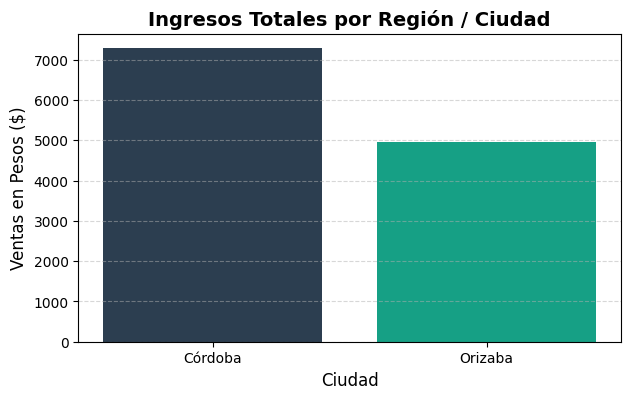

In [25]:
# Consulta analítica mediante JOINs para obtener los ingresos por ciudad
query_region = """
SELECT s.ciudad, SUM(v.total_venta) as ingresos_totales
FROM fact_ventas v
JOIN dim_sucursal s ON v.id_sucursal = s.id_sucursal
GROUP BY s.ciudad;
"""
df_resumen_region = pd.read_sql(query_region, engine)

# Construcción de la visualización
plt.figure(figsize=(7, 4))
plt.bar(df_resumen_region['ciudad'], df_resumen_region['ingresos_totales'], color=['#2c3e50', '#16a085'])
plt.title('Ingresos Totales por Región / Ciudad', fontsize=14, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Ventas en Pesos ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Guardar imagen para el reporte PDF
plt.savefig('evidencia_ventas_region.png', bbox_inches='tight')
plt.show()

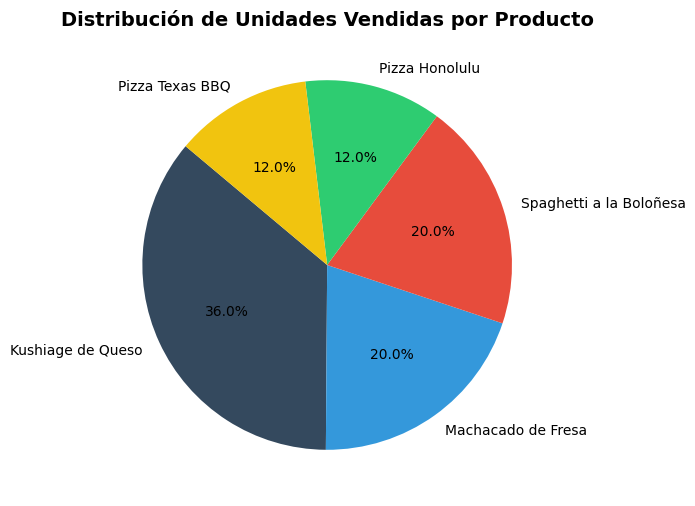

In [26]:
# Consulta analítica para determinar las unidades totales vendidas por artículo
query_productos = """
SELECT p.nombre_producto, SUM(v.cantidad) as unidades_vendidas
FROM fact_ventas v
JOIN dim_producto p ON v.id_producto = p.id_producto
GROUP BY p.nombre_producto
ORDER BY unidades_vendidas DESC;
"""
df_resumen_productos = pd.read_sql(query_productos, engine)

# Construcción del gráfico de pastel
plt.figure(figsize=(6, 6))
plt.pie(df_resumen_productos['unidades_vendidas'], 
        labels=df_resumen_productos['nombre_producto'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=['#34495e', '#3498db', '#e74c3c', '#2ecc71', '#f1c40f'])
plt.title('Distribución de Unidades Vendidas por Producto', fontsize=14, fontweight='bold')

# Guardar imagen para el reporte PDF
plt.savefig('evidencia_productos_vendidos.png', bbox_inches='tight')
plt.show()